In [1]:
import sys
# For notebooks inside research/ftir_hips_chem/:
sys.path.insert(0, './scripts')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.cross_decomposition import PLSRegression

# Config + data
from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
)

# Exclusions (the IMPROVE RDS cohort already carries its model exclusions; no new
# sample is silently removed here—eligibility and missing-reference rows are audited.)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

# Data loading / matching
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors

# Plotting—importing applies the repository white-background default.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

from pls_transfer import (
    FTIRTransferPaths, load_current_pls_model, vip_scores,
    select_components_cv, nested_cv_predictions, regression_metrics,
    score_metric, project_scores, mahalanobis_distance_squared,
    pairwise_score_distance_squared, spectral_q_residual, offset_correct,
    vip_overlap_summary, summarize_vip_bands, spaced_peak_table,
)

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True)
PATHS = FTIRTransferPaths.defaults()
TABLE_DIR = Path('output/tables/pls_transfer')
PLOT_DIR = Path('output/plots/pls_transfer')
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Train on IMPROVE HIPS, predict Addis HIPS, then compare Addis-only VIP

## tl;dr

The IMPROVE HIPS calibration does **not** transfer to Addis. After correcting the response to a
filter-loading basis (HIPS optical depth τ), the 916-sample, site-held-out IMPROVE model predicts a
median Addis Fabs of **15.0** versus **47.1 observed** (n = 239; RMSE **34.38**, mean bias **−33.01**).
The deliberately unit-mismatched direct-Fabs fit is worse (RMSE **46.52**). An Addis-only HIPS model
reaches nested-CV RMSE **3.82**, R² **0.883**, slope **0.912**, and intercept **+4.35**. Its top 200 VIP
wavenumbers have **zero exact overlap** with IMPROVE's top 200 despite a broader rank correlation of
0.797, showing that the highest-priority spectral features change materially.

## Context & Methods

The response is HIPS filter optical depth, reconstructed as
`tau = Fabs × sampled volume / (100 × deposit area)`. This puts the HIPS reference on a
filter-loading basis comparable to FTIR absorbance; predictions are converted back to Fabs
for stakeholder-facing evaluation. The result remains independent of the unresolved
MAC = 6 versus 10 question.
The IMPROVE component count is selected by holding out entire IMPROVE sites. The Addis-only
result uses nested cross-validation and averages replicate FTIR scans before any split.

### Key Assumptions

- IMPROVE and SPARTAN `Fabs` are comparable HIPS outputs; protocol differences remain a caveat.
- The raw 2722-point spectra share a grid and are modeled with `scale=False`, matching the R models.
- HIPS is an independent optical comparator, not absolute EC ground truth.

## Data

In [2]:
arrays = np.load(PATHS.ftir_dir / 'apps/apps_data.npz', allow_pickle=True)
wn = arrays['wn'].astype(float)
calibration_rows = pd.DataFrame({
    'row': np.arange(len(arrays['EC_id'])),
    'AnalysisId': arrays['EC_id'].astype(int),
    'FilterId': arrays['EC_fid'].astype(int),
    'Site': arrays['EC_site'].astype(str),
})
improve_hips_raw = pd.read_csv(
    PATHS.ftir_dir / 'local_db/tables/results_hips.csv',
    usecols=['MatchedFilterId', 'Parameter', 'Value', 'AverageFlowRate',
             'ElapsedTime', 'SampleDepositArea'],
)
improve_hips = (improve_hips_raw[improve_hips_raw['Parameter'].str.casefold() == 'fabs']
                .drop_duplicates('MatchedFilterId'))
improve_join = calibration_rows.merge(
    improve_hips[['MatchedFilterId', 'Value', 'AverageFlowRate',
                  'ElapsedTime', 'SampleDepositArea']],
    left_on='FilterId', right_on='MatchedFilterId', how='left', validate='one_to_one')
improve_join['SampleVolume_m3'] = (
    improve_join['AverageFlowRate'] / 1000.0 * improve_join['ElapsedTime']
)
improve_join['HIPS_tau'] = (
    improve_join['Value'] * improve_join['SampleVolume_m3'] /
    (100.0 * improve_join['SampleDepositArea'])
)
eligible = (improve_join['Value'].notna() & improve_join['SampleVolume_m3'].gt(0) &
            improve_join['SampleDepositArea'].gt(0) & improve_join['HIPS_tau'].notna())
X_improve_hips = arrays['EC_X'][improve_join.loc[eligible, 'row'].to_numpy()].astype(float)
y_improve_fabs = improve_join.loc[eligible, 'Value'].to_numpy(float)
y_improve_hips = improve_join.loc[eligible, 'HIPS_tau'].to_numpy(float)
site_improve_hips = improve_join.loc[eligible, 'Site'].to_numpy()

In [3]:
# One spectrum per physical filter: average replicate scans before model fitting/CV.
raw_etad = pd.read_csv(PATHS.etad_dir / 'ETAD_FTIR_spectra.csv')
etad_meta = pd.read_csv(PATHS.etad_dir / 'ETAD_metadata.csv')
wcols = sorted([c for c in raw_etad.columns if c not in ('SampleAnalysisId', 'MediaId')],
               key=lambda value: -float(value))
assert np.allclose(np.array([float(c) for c in wcols]), wn)
etad_spectra = raw_etad.groupby('MediaId', as_index=False)[wcols].mean()

# The primary file is newer and has 239 ETAD HIPS results versus 190 in the user-listed backup.
hips_primary = pd.read_csv(PATHS.spartan_hips_primary, encoding='cp1252')
hips_backup = pd.read_csv(PATHS.spartan_hips_backup, encoding='cp1252')
hips_fields = ['FilterId', 'Fabs', 'tau', 'DepositArea', 'Volume']
primary_etad = hips_primary[hips_primary['Site'] == 'ETAD'][hips_fields].drop_duplicates('FilterId')
backup_etad = hips_backup[hips_backup['Site'] == 'ETAD'][hips_fields].drop_duplicates('FilterId')
source_compare = primary_etad.merge(backup_etad, on='FilterId', suffixes=('_primary', '_backup'))
source_audit = pd.DataFrame([{
    'primary_nonnull': int(primary_etad['Fabs'].notna().sum()),
    'backup_nonnull': int(backup_etad['Fabs'].notna().sum()),
    'overlap_n': int(source_compare[['Fabs_primary', 'Fabs_backup']].dropna().shape[0]),
    'overlap_max_abs_difference': float(np.nanmax(np.abs(source_compare['Fabs_primary'] - source_compare['Fabs_backup']))),
    'primary_tau_formula_max_abs_difference': float(np.nanmax(np.abs(
        primary_etad['Fabs'] * primary_etad['Volume'] /
        (100.0 * primary_etad['DepositArea']) - primary_etad['tau']))),
}])

etad = (etad_spectra.merge(etad_meta, on='MediaId', how='left')
        .merge(primary_etad.rename(columns={'FilterId': 'ExternalFilterId'}),
               on='ExternalFilterId', how='left'))
etad['has_spectrum'] = etad[wcols].notna().all(axis=1)
etad['has_hips'] = etad['Fabs'].notna()
etad['positive_volume'] = etad['SampleVolume_m3'].gt(0)
etad['positive_deposit_area'] = etad['DepositArea'].gt(0)
etad_eval = etad[etad['has_spectrum'] & etad['has_hips'] & etad['positive_volume'] & etad['positive_deposit_area']].copy()
etad_eval['HIPS_tau'] = (
    etad_eval['Fabs'] * etad_eval['SampleVolume_m3'] / (100.0 * etad_eval['DepositArea'])
)
X_etad = etad_eval[wcols].to_numpy(float)
y_etad = etad_eval['Fabs'].to_numpy(float)
y_etad_tau = etad_eval['HIPS_tau'].to_numpy(float)

In [4]:
data_audit = pd.DataFrame([
    {'cohort': 'IMPROVE spectra available', 'n': len(calibration_rows)},
    {'cohort': 'IMPROVE matched to HIPS Fabs + volume + area', 'n': len(y_improve_hips)},
    {'cohort': 'Addis unique filters with spectra', 'n': len(etad_spectra)},
    {'cohort': 'Addis spectra + HIPS + positive volume', 'n': len(etad_eval)},
])
data_audit.to_csv(TABLE_DIR / 'hips_transfer_data_audit.csv', index=False)
source_audit.to_csv(TABLE_DIR / 'spartan_hips_source_reconciliation.csv', index=False)
display(data_audit)
display(source_audit)

,cohort,n
0,IMPROVE spectra available,935
1,IMPROVE matched to HIPS Fabs + volume + area,916
2,Addis unique filters with spectra,296
3,Addis spectra + HIPS + positive volume,239


,primary_nonnull,backup_nonnull,overlap_n,overlap_max_abs_difference,primary_tau_formula_max_abs_difference
0,239,190,190,0.0,5.551115e-15


## Results

### 1. IMPROVE HIPS model: choose complexity by holding out whole sites

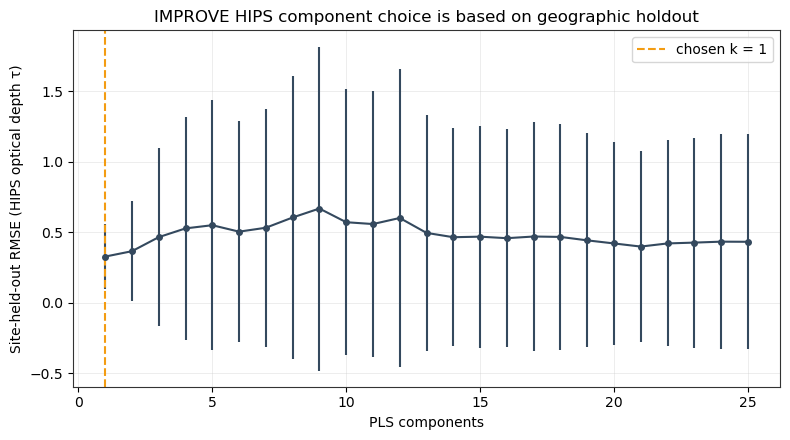

Chosen IMPROVE HIPS components: 1


In [5]:
improve_k, improve_curve = select_components_cv(
    X_improve_hips, y_improve_hips, range(1, 26),
    groups=site_improve_hips, n_splits=5, random_state=42)
improve_curve.to_csv(TABLE_DIR / 'improve_hips_group_cv_curve.csv', index=False)
improve_model = PLSRegression(n_components=improve_k, scale=False).fit(X_improve_hips, y_improve_hips)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(improve_curve['n_components'], improve_curve['rmse_mean'],
            yerr=improve_curve['rmse_sd'], color='#34495E', marker='o', ms=4)
ax.axvline(improve_k, color=SITES['Addis_Ababa']['color'], ls='--', label=f'chosen k = {improve_k}')
ax.set(xlabel='PLS components', ylabel='Site-held-out RMSE (HIPS optical depth τ)',
       title='IMPROVE HIPS component choice is based on geographic holdout')
ax.legend(); fig.tight_layout()
fig.savefig(PLOT_DIR / 'improve_hips_component_selection.png', dpi=180, bbox_inches='tight')
plt.show()
print('Chosen IMPROVE HIPS components:', improve_k)

### 2. Transfer the IMPROVE HIPS model to Addis and benchmark an Addis-only model

In [6]:
transfer_tau = improve_model.predict(X_etad).ravel()
transfer_prediction = (
    transfer_tau * 100.0 * etad_eval['DepositArea'].to_numpy() /
    etad_eval['SampleVolume_m3'].to_numpy()
)
transfer_metrics = regression_metrics(y_etad, transfer_prediction)

addis_nested_tau, addis_nested_folds = nested_cv_predictions(
    X_etad, y_etad_tau, range(1, 16), outer_splits=5, inner_splits=4, random_state=42)
addis_nested_prediction = (
    addis_nested_tau * 100.0 * etad_eval['DepositArea'].to_numpy() /
    etad_eval['SampleVolume_m3'].to_numpy()
)
addis_cv_metrics = regression_metrics(y_etad, addis_nested_prediction)
addis_k, addis_curve = select_components_cv(
    X_etad, y_etad_tau, range(1, 16), n_splits=5, random_state=42)
addis_model = PLSRegression(n_components=addis_k, scale=False).fit(X_etad, y_etad_tau)

# Deliberately unit-mismatched sensitivity: direct Fabs ignores sample volume/area.
naive_k, naive_curve = select_components_cv(
    X_improve_hips, y_improve_fabs, range(1, 26),
    groups=site_improve_hips, n_splits=5, random_state=42)
naive_model = PLSRegression(n_components=naive_k, scale=False).fit(X_improve_hips, y_improve_fabs)
naive_prediction = naive_model.predict(X_etad).ravel()
naive_metrics = regression_metrics(y_etad, naive_prediction)

metric_table = pd.DataFrame([
    {'model': 'IMPROVE HIPS → Addis external test', **transfer_metrics,
     'components': improve_k, 'validation': 'external site transfer'},
    {'model': 'Addis-only HIPS', **addis_cv_metrics,
     'components': addis_k, 'validation': 'nested 5-fold CV'},
    {'model': 'Naive direct-Fabs sensitivity (unit mismatched)', **naive_metrics,
     'components': naive_k, 'validation': 'external site transfer; diagnostic only'},
])
metric_table.to_csv(TABLE_DIR / 'hips_transfer_model_metrics.csv', index=False)
addis_nested_folds.to_csv(TABLE_DIR / 'addis_nested_cv_component_choices.csv', index=False)
addis_curve.to_csv(TABLE_DIR / 'addis_hips_cv_curve.csv', index=False)
transfer_predictions = etad_eval[['MediaId', 'ExternalFilterId', 'Fabs', 'HIPS_tau',
                                  'SampleVolume_m3', 'DepositArea']].copy()
transfer_predictions['IMPROVE_HIPS_transfer_prediction'] = transfer_prediction
transfer_predictions['Addis_HIPS_nested_CV_prediction'] = addis_nested_prediction
transfer_predictions['naive_direct_Fabs_prediction'] = naive_prediction
transfer_predictions.to_csv(TABLE_DIR / 'addis_hips_transfer_predictions.csv', index=False)
display(metric_table)

,model,n,slope,intercept,R2,RMSE,MAE,bias,median_bias,components,validation
0,IMPROVE HIPS → Addis external test,239,0.220490,4.936249,0.264248,34.378154,33.014410,-33.014410,-31.970782,1,external site transfer
1,Addis-only HIPS,239,0.912034,4.346174,0.882805,3.823652,2.662677,0.063528,0.003166,14,nested 5-fold CV
2,Naive direct-Fabs sensitivity (unit mismatched),239,0.017188,2.629980,0.348250,46.521645,45.218515,-45.218515,-43.605527,1,external site transfer; diagnostic only


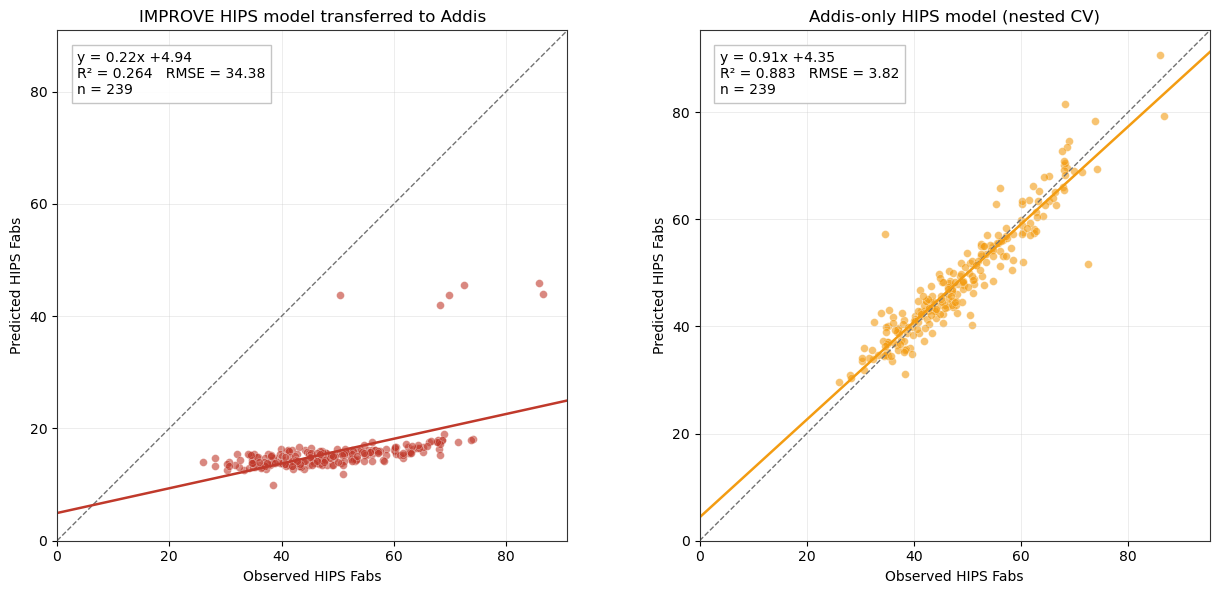

In [7]:
def crossplot(ax, observed, predicted, title, color):
    metrics = regression_metrics(observed, predicted)
    lo = min(0.0, np.nanmin(observed), np.nanmin(predicted))
    hi = max(np.nanmax(observed), np.nanmax(predicted)) * 1.05
    ax.scatter(observed, predicted, s=32, alpha=0.6, color=color,
               edgecolors='white', linewidths=0.3)
    ax.plot([lo, hi], [lo, hi], '--', color='0.45', lw=1)
    xline = np.array([lo, hi])
    ax.plot(xline, metrics['slope'] * xline + metrics['intercept'], color=color, lw=1.8)
    ax.set(xlim=(lo, hi), ylim=(lo, hi), aspect='equal', xlabel='Observed HIPS Fabs',
           ylabel='Predicted HIPS Fabs', title=title)
    ax.text(0.04, 0.96,
            f"y = {metrics['slope']:.2f}x {metrics['intercept']:+.2f}\n"
            f"R² = {metrics['R2']:.3f}   RMSE = {metrics['RMSE']:.2f}\n"
            f"n = {metrics['n']}", transform=ax.transAxes, va='top',
            bbox={'facecolor': 'white', 'edgecolor': '0.75', 'alpha': 0.9})

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
crossplot(axes[0], y_etad, transfer_prediction,
          'IMPROVE HIPS model transferred to Addis', '#C0392B')
crossplot(axes[1], y_etad, addis_nested_prediction,
          'Addis-only HIPS model (nested CV)', SITES['Addis_Ababa']['color'])
fig.tight_layout()
fig.savefig(PLOT_DIR / 'improve_to_addis_hips_transfer.png', dpi=180, bbox_inches='tight')
plt.show()

### 3. Compare the two HIPS models' VIP profiles

,spearman_r,important_a_n,important_b_n,important_jaccard,top_n,top_n_overlap,top_n_overlap_fraction,a_vip_mass_on_b_important
0,0.796701,1250,1020,0.628407,200,0,0.0,0.565403


model,Addis HIPS,IMPROVE HIPS
band,,
O-H / N-H region,0.195130,0.328476
aliphatic C-H stretch,0.056980,0.101984
amide / aromatic / N-H region,0.033803,0.026387
carbonyl region,0.039807,0.040965
fingerprint region,0.321015,0.185913


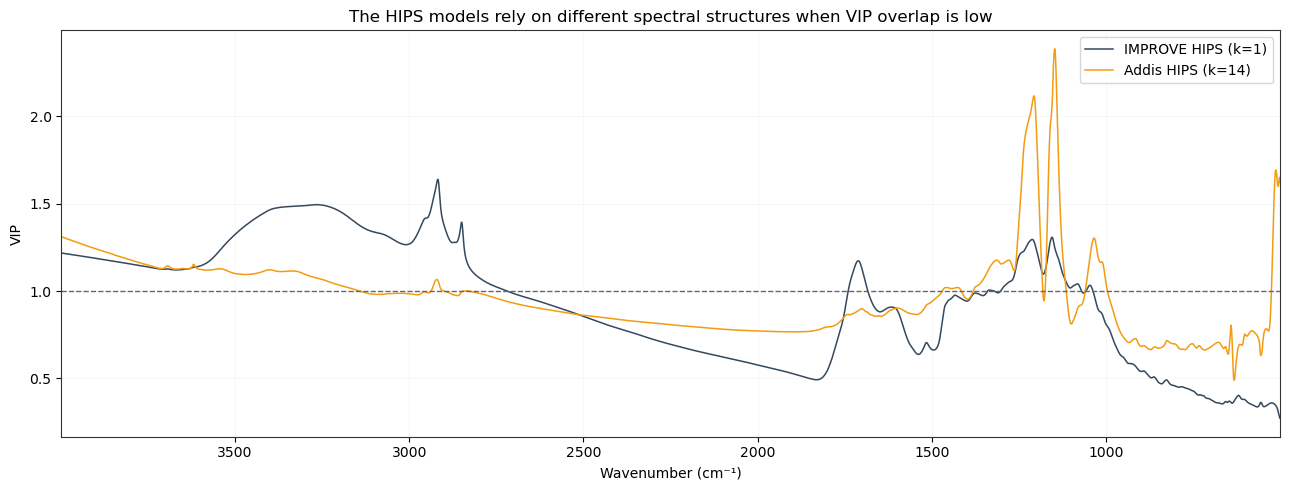

In [8]:
improve_vip = vip_scores(improve_model)
addis_vip = vip_scores(addis_model)
vip_compare = vip_overlap_summary(improve_vip, addis_vip, threshold=1.0, top_n=200)
vip_compare_table = pd.DataFrame([vip_compare])
vip_compare_table.to_csv(TABLE_DIR / 'improve_addis_hips_vip_overlap.csv', index=False)

hips_vip_profile = pd.DataFrame({
    'wavenumber_cm-1': wn,
    'IMPROVE_HIPS_VIP': improve_vip,
    'Addis_HIPS_VIP': addis_vip,
})
hips_vip_profile.to_csv(TABLE_DIR / 'improve_addis_hips_vip_profiles.csv', index=False)
hips_bands = pd.concat([
    summarize_vip_bands(wn, improve_vip).assign(model='IMPROVE HIPS'),
    summarize_vip_bands(wn, addis_vip).assign(model='Addis HIPS'),
], ignore_index=True)
hips_bands.to_csv(TABLE_DIR / 'improve_addis_hips_vip_bands.csv', index=False)
display(vip_compare_table)
display(hips_bands.pivot(index='band', columns='model', values='vip2_mass_fraction'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(wn, improve_vip, color='#34495E', lw=1.1, label=f'IMPROVE HIPS (k={improve_k})')
ax.plot(wn, addis_vip, color=SITES['Addis_Ababa']['color'], lw=1.1,
        label=f'Addis HIPS (k={addis_k})')
ax.axhline(1, color='0.4', ls='--', lw=1)
ax.set_xlim(wn.max(), wn.min())
ax.set(xlabel='Wavenumber (cm⁻¹)', ylabel='VIP',
       title='The HIPS models rely on different spectral structures when VIP overlap is low')
ax.legend(); ax.grid(alpha=0.2); fig.tight_layout()
fig.savefig(PLOT_DIR / 'improve_addis_hips_vip_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## Takeaways

- The requested deviation is large even after volume/deposit-area normalization, so it cannot be
  dismissed as the naive Fabs unit mismatch.
- Addis spectra contain enough repeatable information to predict Addis HIPS internally, but an
  Addis-only HIPS calibration is a mechanism probe—not a TOR EC calibration and not independent
  evidence that HIPS is absolute EC truth.
- Relative VIP emphasis shifts from the IMPROVE O–H/N–H region (**32.8%** of squared-VIP mass) toward
  the Addis fingerprint region (**32.1%**, versus **18.6%** in IMPROVE). Exact peak assignments remain
  uncertain because FTIR bands overlap.
- The newer SPARTAN HIPS source supplies 239 matched Addis filters versus 190 in the user-listed
  backup; all 190 overlapping Fabs values agree exactly, and the τ reconstruction matches the stored
  HIPS τ to numerical precision.